In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("heart_disease_risk_2026.csv")

# Data Quality Checks

In [3]:
df

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,8996,36,Female,108,63,178,68,82,158,96,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,Female,112,73,213,54,139,102,125,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,Female,144,93,198,66,113,79,102,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,Female,130,70,220,68,135,109,104,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1


In [10]:
# Column names
df.columns

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='object')

In [4]:
df.head(10)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
5,6,50,Female,122,71,147,46,101,41,134,...,True,Former,3.3,190,5.9,55.1,False,6857,82.6,0
6,7,50,Female,133,85,227,63,124,194,109,...,False,Never,5.1,91,8.2,82.2,True,8466,63.7,0
7,8,58,Female,133,81,141,54,99,40,118,...,True,Current,2.5,92,6.4,45.5,True,6769,42.4,1
8,9,51,Female,121,64,219,84,104,85,136,...,False,Former,2.8,266,9.0,65.6,True,7648,53.5,0
9,10,51,Male,126,77,172,50,104,115,132,...,True,Former,6.1,89,9.1,58.7,False,7531,53.2,0


In [11]:
# Shape
df.shape

(9000, 27)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [6]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

patient_id                     int64
age                            int64
sex                           object
resting_bp_systolic            int64
resting_bp_diastolic           int64
cholesterol_total              int64
hdl                            int64
ldl                            int64
triglycerides                  int64
fasting_blood_sugar            int64
hba1c                        float64
bmi                          float64
resting_heart_rate             int64
max_heart_rate_achieved        int64
chest_pain_type               object
exercise_induced_angina         bool
st_depression                float64
family_history                  bool
smoker_status                 object
alcohol_units_per_week       float64
exercise_minutes_per_week      int64
sleep_hours                  float64
stress_score                 float64
wearable_owner                  bool
daily_steps                    int64
diet_quality_score           float64
has_heart_disease              int64
d

In [9]:
df["sex"].value_counts()

sex
Male      4731
Female    4269
Name: count, dtype: int64

In [12]:
#Duplicate Records
df.isnull().sum()

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

In [14]:
df.nunique()

patient_id                   9000
age                            73
sex                             2
resting_bp_systolic            93
resting_bp_diastolic           71
cholesterol_total             200
hdl                            81
ldl                           163
triglycerides                 281
fasting_blood_sugar           136
hba1c                          45
bmi                           241
resting_heart_rate             60
max_heart_rate_achieved       115
chest_pain_type                 4
exercise_induced_angina         2
st_depression                  63
family_history                  2
smoker_status                   3
alcohol_units_per_week        308
exercise_minutes_per_week     332
sleep_hours                    77
stress_score                  860
wearable_owner                  2
daily_steps                  5414
diet_quality_score            763
has_heart_disease               2
dtype: int64

# EDA

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['patient_id', 'age', 'resting_bp_systolic', 'resting_bp_diastolic',
       'cholesterol_total', 'hdl', 'ldl', 'triglycerides',
       'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate',
       'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week',
       'exercise_minutes_per_week', 'sleep_hours', 'stress_score',
       'daily_steps', 'diet_quality_score', 'has_heart_disease'],
      dtype='object')

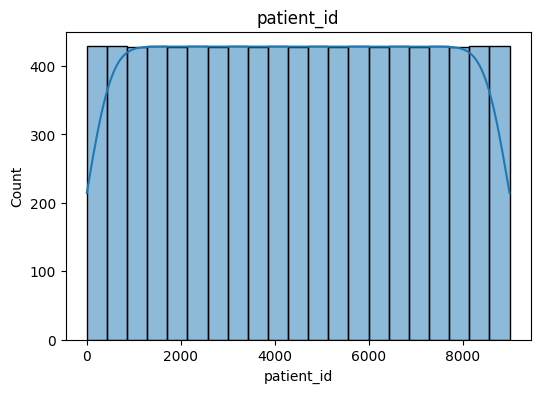

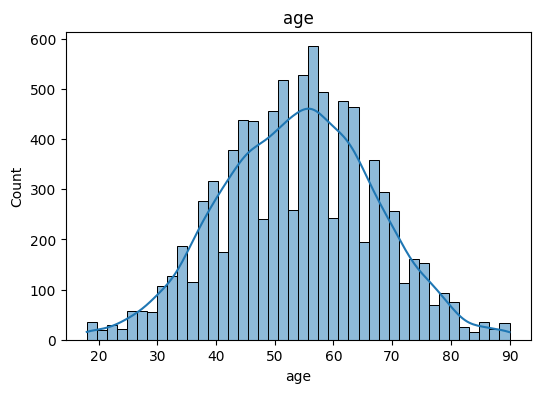

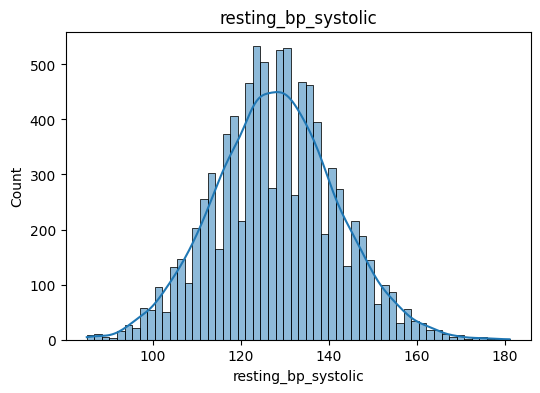

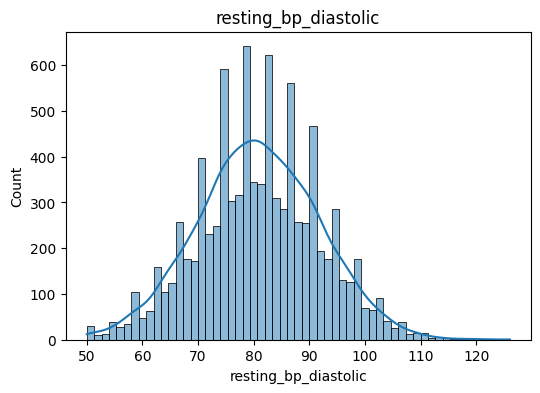

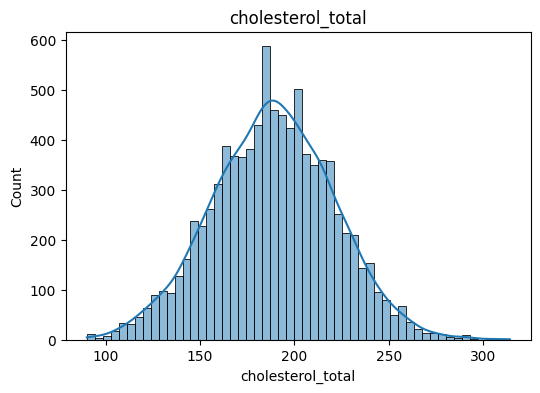

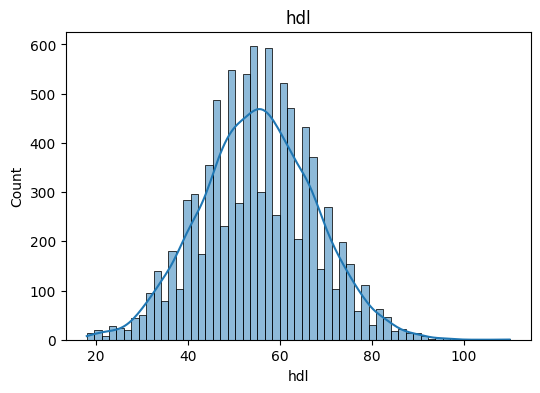

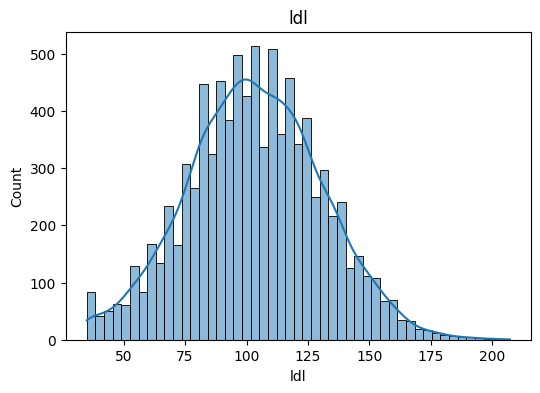

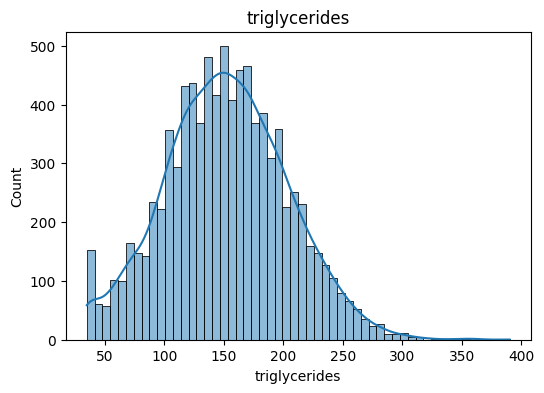

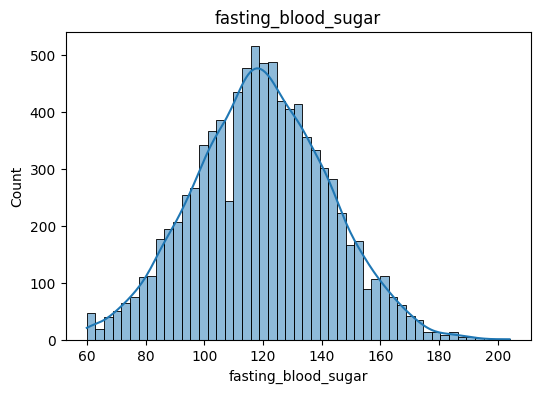

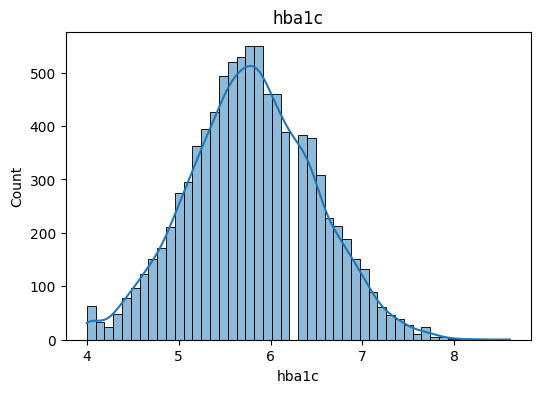

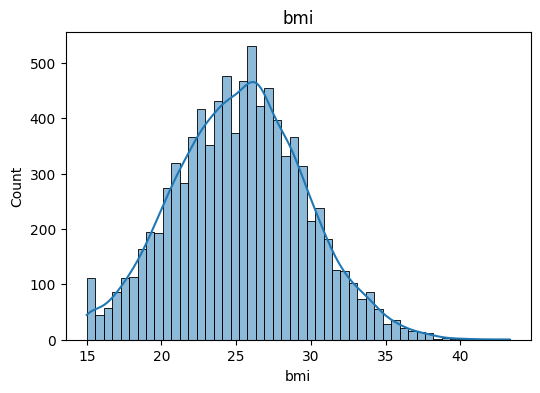

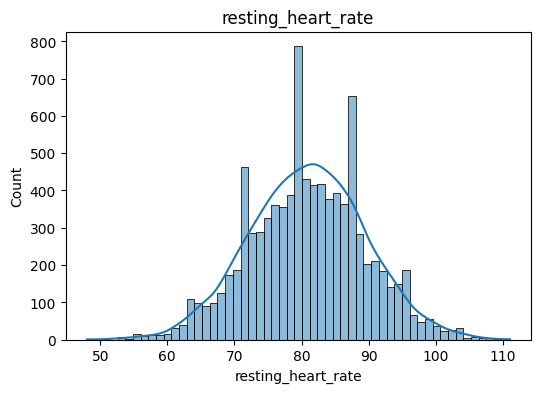

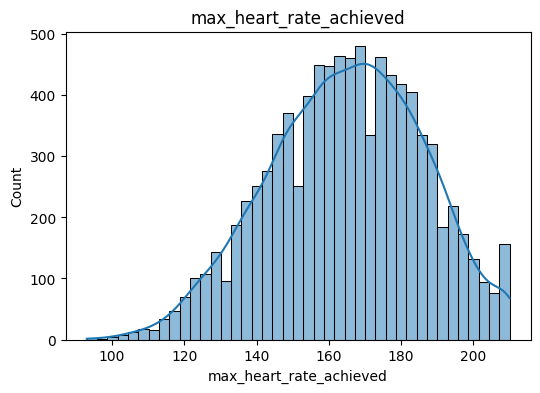

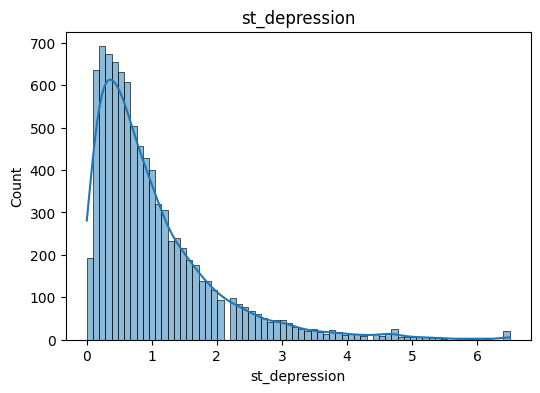

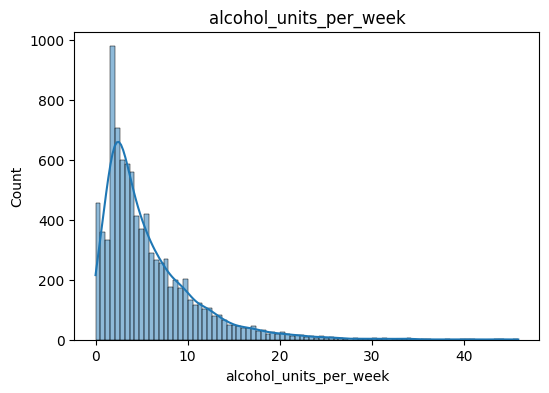

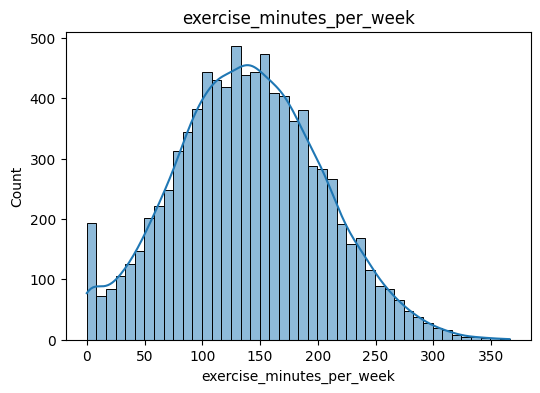

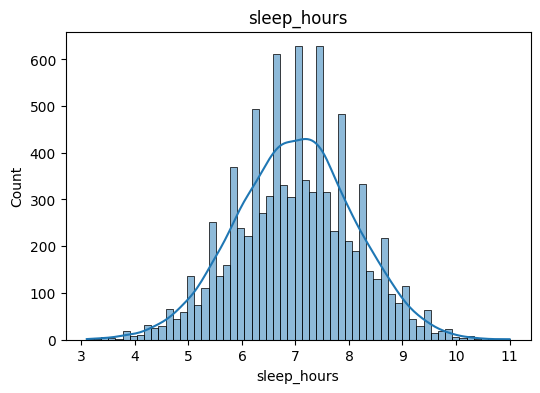

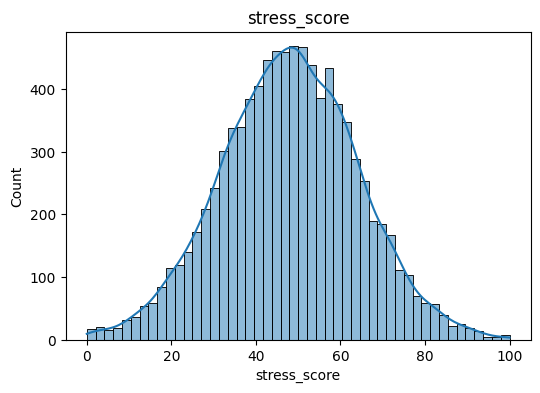

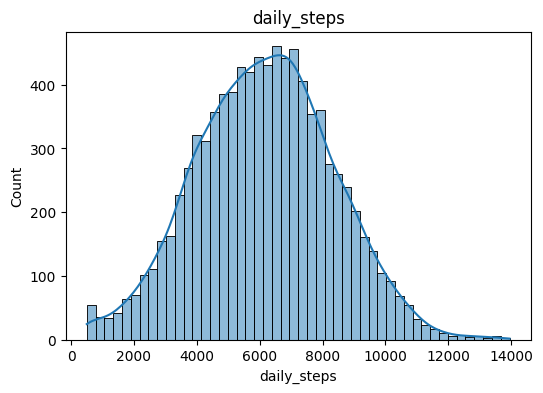

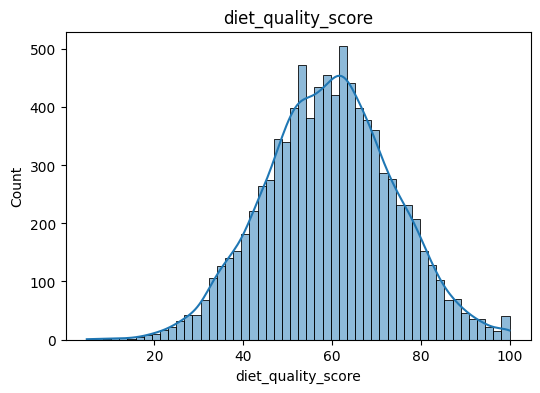

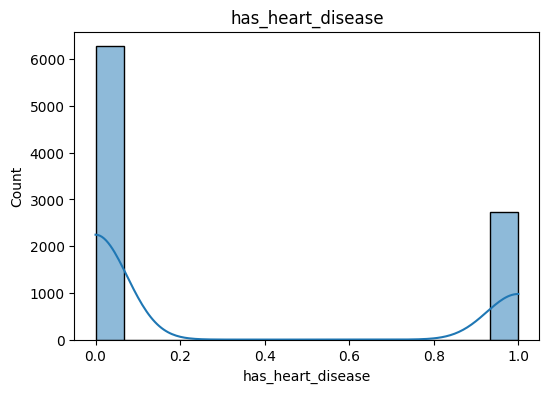

In [26]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

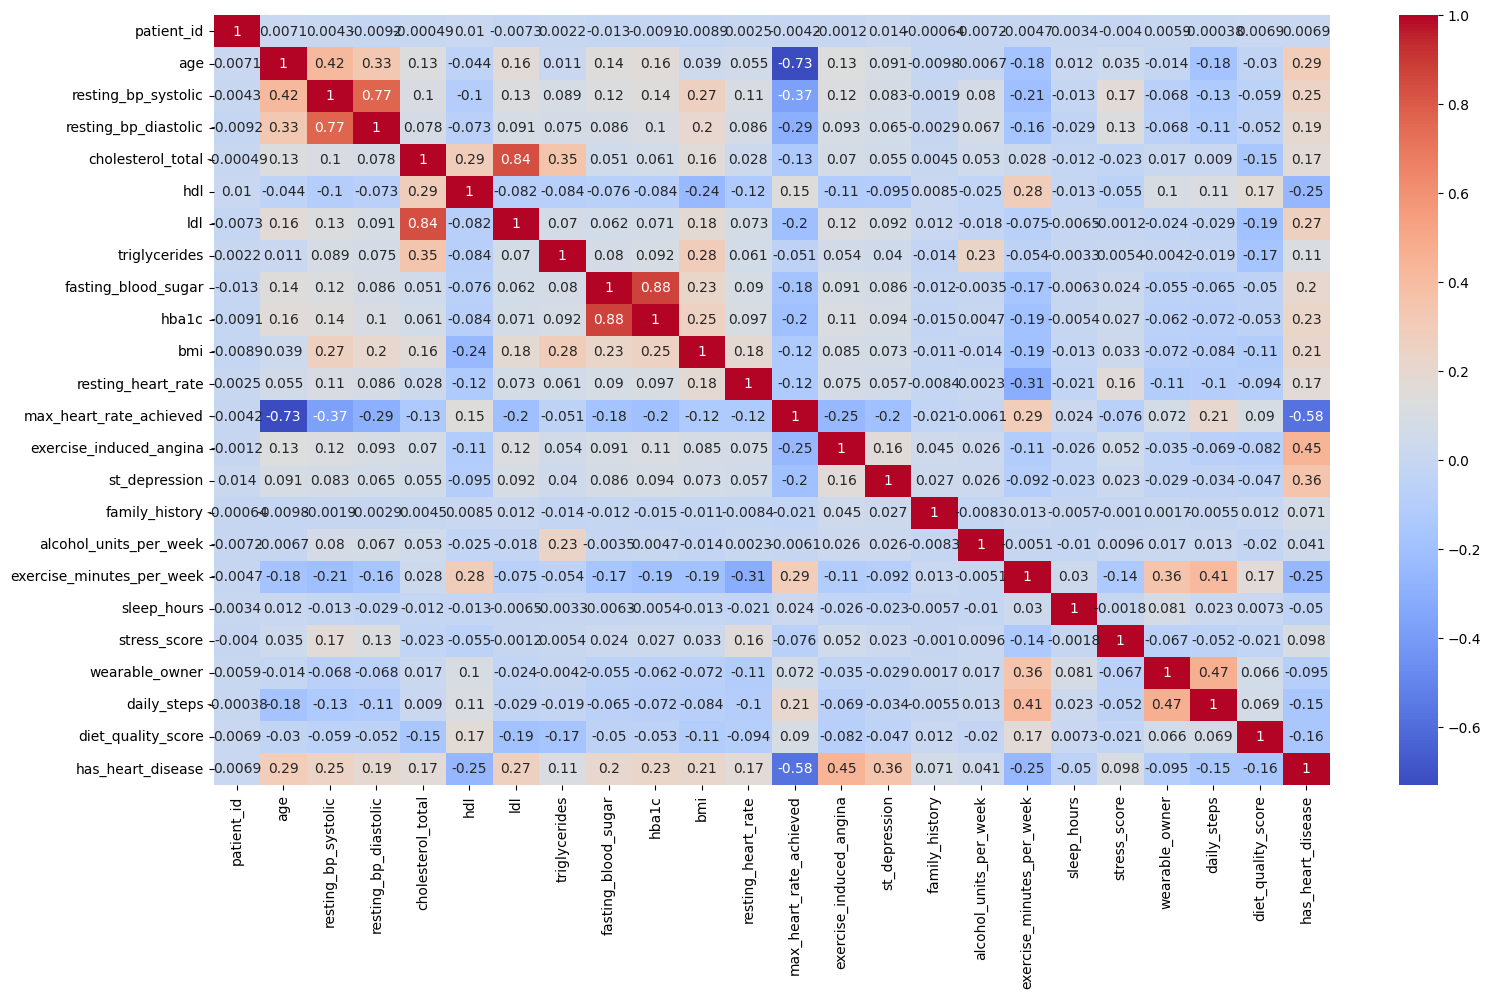

In [27]:
plt.figure(figsize=(18,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

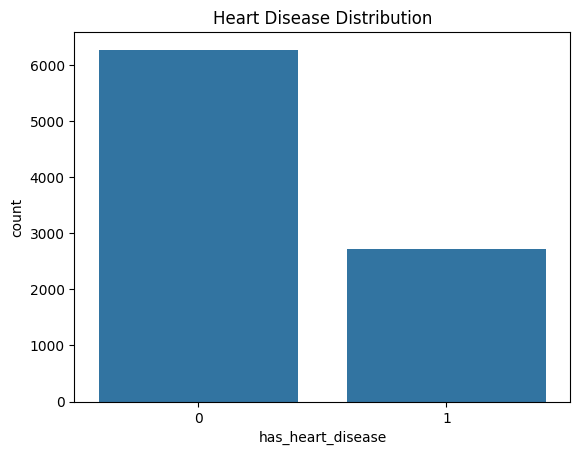

In [29]:
#Heart Disease Distribution
sns.countplot(x='has_heart_disease', data=df)

plt.title("Heart Disease Distribution")

plt.show()

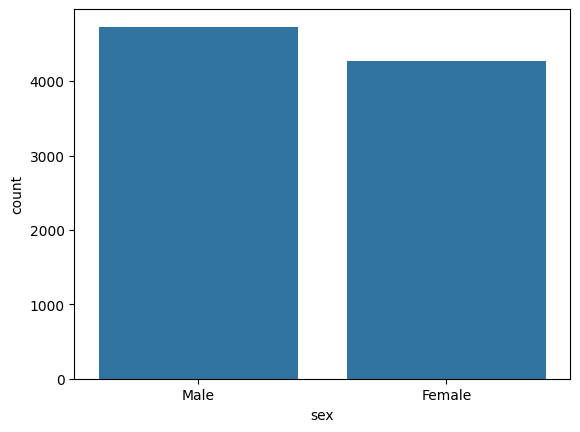

In [30]:
#Gender Distribution


sns.countplot(x='sex', data=df)

plt.show()

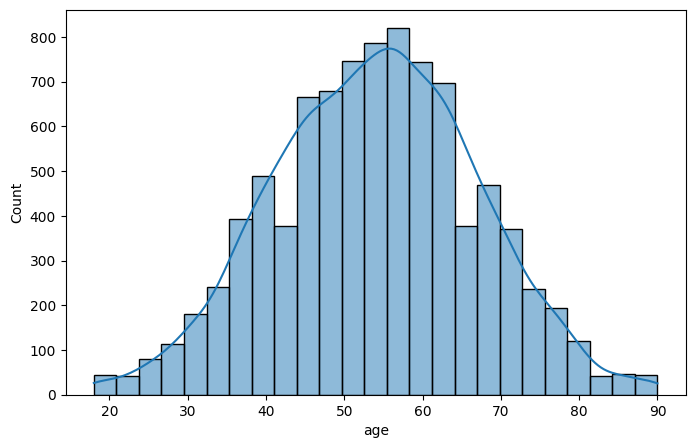

In [31]:
#Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=25, kde=True)
plt.show()

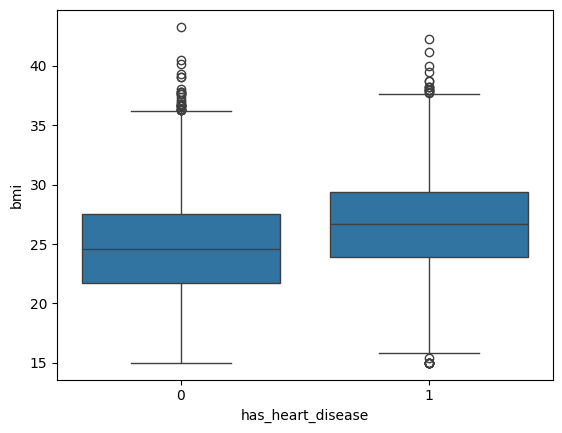

In [32]:
# BMI vs Heart Disease
sns.boxplot(x='has_heart_disease',
            y='bmi',
            data=df)

plt.show()

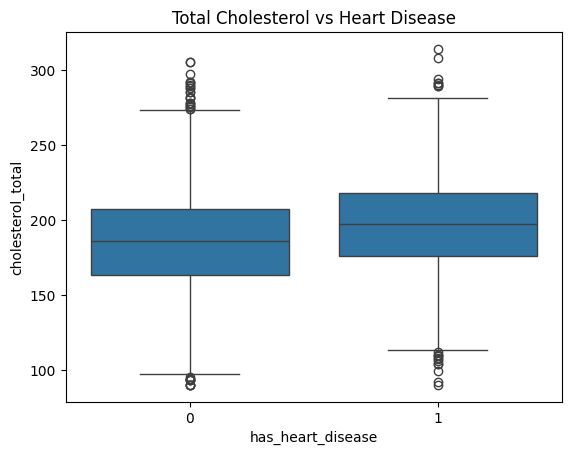

In [40]:
#Cholesterol vs Heart Disease
sns.boxplot(
    x='has_heart_disease',
    y='cholesterol_total',
    data=df
)

plt.title("Total Cholesterol vs Heart Disease")
plt.show()

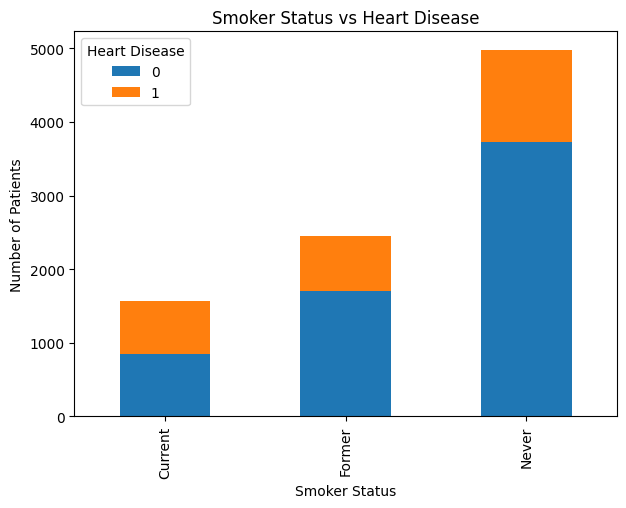

In [43]:
smoking_hd = pd.crosstab(df['smoker_status'], df['has_heart_disease'])

smoking_hd.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title("Smoker Status vs Heart Disease")
plt.xlabel("Smoker Status")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

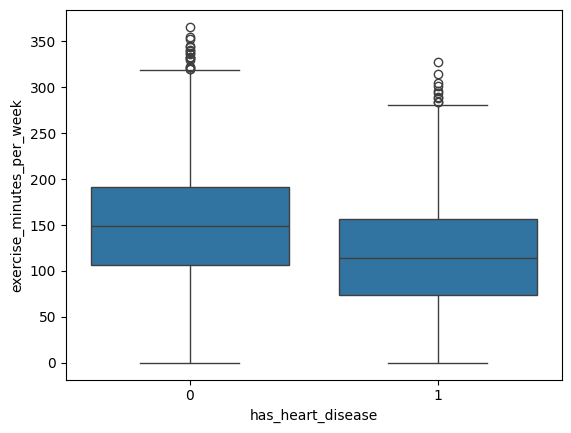

In [36]:
# Exercise vs Heart Disease
sns.boxplot(x='has_heart_disease',
            y='exercise_minutes_per_week',
            data=df)

plt.show()

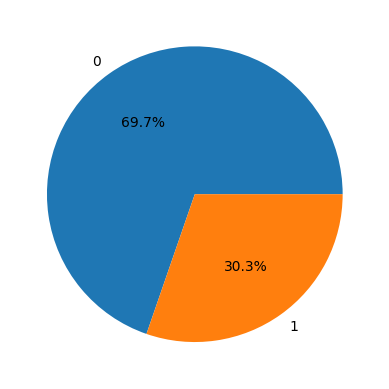

In [35]:
# Disease Percentage
df['has_heart_disease'].value_counts().plot(    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()